In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
import re
from gensim.models import Word2Vec
from nltk.stem import PorterStemmer

In [6]:
# 
Kaynak: (Örn: Google Play Store / App Store Yorumları.((KAGGLEDAN ALINDI.)

Sütun Yapısı: Tarih,Platform,Ülke,Yorum,Yildiz_Puani,Kullanici_ID,Sorun-var-mı,Begeni-sayisi,Begenmeme-sayisi,Etiket.


In [15]:
df=pd.read_csv("mobilyorumdata.csv")
df.head(3)

,Tarih,platform,Ülke,Yorum,Yıldız,Kullanici_id,Sorun-var-mı,begeni_sayisi,begenmeme-say,label
0,07.07.2023,iOS,Australia,Rota paylaşma özelliğini çok seviyorum. Grup g...,5,13c95471-be12-42f6-95d1-fa3dd104909b,Hayır,1,1,NaN
1,12.08.2023,Android,India,Premium fiyatı biraz yüksek ama özellikler fen...,4,945725ef-7277-4884-b717-9259af1df8d2,Hayır,2,2,NaN
2,12.09.2023,iOS,UK,Seyahat detaylarımı doğrudan WhatsApp üzerinde...,5,e3d956b8-6e00-4099-84ca-f51406e6b3f7,Hayır,5,3,NaN


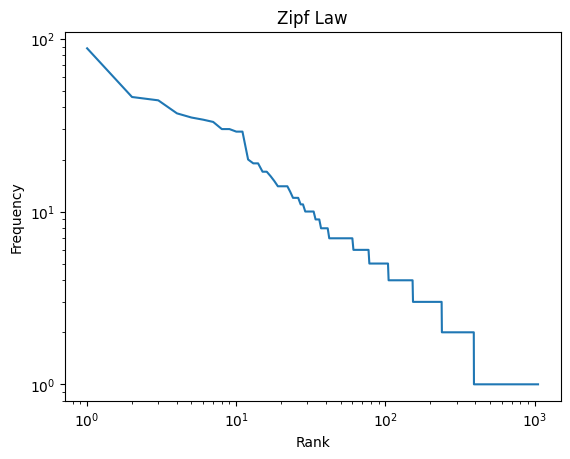

In [17]:

# tüm metinleri birleştir
text = " ".join(df["Yorum"].astype(str))

# kelimelere böl
words = text.split()

# frekans hesapla
freq = Counter(words)

# sıralama
freq_sorted = sorted(freq.values(), reverse=True)

# rank oluştur
ranks = np.arange(1, len(freq_sorted)+1)

# log-log çizim
plt.figure()
plt.loglog(ranks, freq_sorted)
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("Zipf Law")
plt.show()

In [18]:
#PREPROCESSİNG KISMI


In [ ]:
#TEMİZLİK

In [19]:
#(Noktalama işaretleri olmayan özel karakter kullanılmış dagınık verileri temizledim)
def temizle(text):
    text = re.sub(r"<.*?>", "", text)  # HTML
    text = re.sub(r"[^a-zA-ZğüşöçıİĞÜŞÖÇ\s]", "", text)  # özel karakter
    return text

df["clean"] = df["Yorum"].apply(temizle)

# önce/sonra göster
print(df["Yorum"][0])
print(df["clean"][0])

Rota paylaşma özelliğini çok seviyorum. Grup gezilerini planlamayı çok daha kolay hale getiriyor!
Rota paylaşma özelliğini çok seviyorum Grup gezilerini planlamayı çok daha kolay hale getiriyor


In [20]:
#Metni normalize ettim aynı kelimeleri aynı formata indirdim hepsini küçük yazdırdım.
df["lower"] = df["clean"].str.lower()

print(df["clean"][0])
print(df["lower"][0])

Rota paylaşma özelliğini çok seviyorum Grup gezilerini planlamayı çok daha kolay hale getiriyor
rota paylaşma özelliğini çok seviyorum grup gezilerini planlamayı çok daha kolay hale getiriyor


In [21]:
#Metni kelimelere böldüm.
df["tokens"] = df["lower"].apply(lambda x: x.split())

print(df["lower"][0])
print(df["tokens"][0])

rota paylaşma özelliğini çok seviyorum grup gezilerini planlamayı çok daha kolay hale getiriyor
['rota', 'paylaşma', 'özelliğini', 'çok', 'seviyorum', 'grup', 'gezilerini', 'planlamayı', 'çok', 'daha', 'kolay', 'hale', 'getiriyor']


In [23]:
#Önemsiz ve anlamsız çok sık geçen kelimeler listesini aldım.
stopwords = ["ve", "bir", "bu", "çok", "ama", "da", "de", "için"]

df["no_stop"] = df["tokens"].apply(lambda x: [w for w in x if w not in stopwords])

print(df["tokens"][0])
print(df["no_stop"][0])

['rota', 'paylaşma', 'özelliğini', 'çok', 'seviyorum', 'grup', 'gezilerini', 'planlamayı', 'çok', 'daha', 'kolay', 'hale', 'getiriyor']
['rota', 'paylaşma', 'özelliğini', 'seviyorum', 'grup', 'gezilerini', 'planlamayı', 'daha', 'kolay', 'hale', 'getiriyor']


In [24]:
#Lemmazation

In [32]:
#Bu adımda Türkçe için uygun lemmatization kütüphanesi kullanılmadığı için stopword temizlenmiş veri lemma çıktısı olarak kabul edilmiştir.
df["lemma"] = df["no_stop"]


In [33]:
df[["no_stop", "lemma"]].head()

,no_stop,lemma
0,"[rota, paylaşma, özelliğini, seviyorum, grup, ...","[rota, paylaşma, özelliğini, seviyorum, grup, ..."
1,"[premium, fiyatı, biraz, yüksek, özellikler, f...","[premium, fiyatı, biraz, yüksek, özellikler, f..."
2,"[seyahat, detaylarımı, doğrudan, whatsapp, üze...","[seyahat, detaylarımı, doğrudan, whatsapp, üze..."
3,"[premium, fiyatı, yüksek, daha, iyi, olabilir]","[premium, fiyatı, yüksek, daha, iyi, olabilir]"
4,"[rezervasyon, deneyimi, sorunsuz]","[rezervasyon, deneyimi, sorunsuz]"


In [29]:

stemmer = PorterStemmer()

df["stem"] = df["no_stop"].apply(lambda x: [stemmer.stem(w) for w in x])

In [34]:
df[["no_stop", "stem"]].head()

,no_stop,stem
0,"[rota, paylaşma, özelliğini, seviyorum, grup, ...","[rota, paylaşma, özelliğini, seviyorum, grup, ..."
1,"[premium, fiyatı, biraz, yüksek, özellikler, f...","[premium, fiyatı, biraz, yüksek, özellikl, fen..."
2,"[seyahat, detaylarımı, doğrudan, whatsapp, üze...","[seyahat, detaylarımı, doğrudan, whatsapp, üze..."
3,"[premium, fiyatı, yüksek, daha, iyi, olabilir]","[premium, fiyatı, yüksek, daha, iyi, olabilir]"
4,"[rezervasyon, deneyimi, sorunsuz]","[rezervasyon, deneyimi, sorunsuz]"


In [35]:
df[["lemma"]].to_csv("lemmatized.csv", index=False)

In [36]:
df[["stem"]].to_csv("stemmed.csv", index=False)